# Etapa 2 · Entrenamiento del CVAE

Objetivo: entrenar un Conditional VAE condicionado a 4 etiquetas (DBS x MED) que genere ventanas de 1.2 s con distribucion similar a la real.

Arquitectura (1D Conv CVAE, q(z|x,c) y p(x|z,c)):
- Encoder: 3 x Conv1D (k=7, s=2) -> aplanar -> concat con c_onehot -> FC -> (mu, logvar) en R^16
- Reparametrizacion z = mu + sigma * eps
- Decoder: concat(z, c_onehot) -> FC -> 3 x ConvTranspose1D -> 1 x 240
- Prior p(z) = N(0, I)

Perdida:
$$
\mathcal{L} = \mathrm{MSE}(x, \hat x) + \lambda_\text{PSD}\cdot\mathrm{MAE}(\mathrm{PSD}(x), \mathrm{PSD}(\hat x)) + \beta(t)\cdot \mathrm{KL}_\text{free-bits}
$$

con beta-annealing 0 -> 1 en 30 epocas y free-bits = 0.5 nats por dimension latente.

In [1]:
# Workaround para macOS Intel + conda: evitar segfault por libomp/MKL duplicado.
# DEBE ir antes de cualquier 'import numpy/scipy/torch'.
import os
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
import numpy as np
import json, math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from scipy import signal as sp_signal

torch.set_num_threads(1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42)
print('device:', device, '| threads:', torch.get_num_threads())

device: cpu | threads: 1


## 1. Cargar productos de la Etapa 1

In [2]:
X_train = np.load('tremor_X_train.npy'); y_train = np.load('tremor_y_train.npy')
X_val   = np.load('tremor_X_val.npy');   y_val   = np.load('tremor_y_val.npy')
X_test  = np.load('tremor_X_test.npy');  y_test  = np.load('tremor_y_test.npy')
with open('label_dict.json') as f:
    LABELS = json.load(f)

WINDOW_LEN = LABELS['window_len']
FS         = LABELS['sampling_rate']
N_COND     = len(LABELS['condition'])
print(f'Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}')
print(f'window {WINDOW_LEN} @ {FS} Hz, conditions = {N_COND}')

Train (7485, 240)  Val (1761, 240)  Test (1899, 240)
window 240 @ 200 Hz, conditions = 4


## 2. Dataset / DataLoader

In [3]:
class TremorDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float().unsqueeze(1)
        self.c = torch.from_numpy(y[:, 0]).long()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.c[i]

train_loader = DataLoader(TremorDS(X_train, y_train), batch_size=64, shuffle=True, drop_last=True)
val_loader   = DataLoader(TremorDS(X_val,   y_val),   batch_size=64, shuffle=False)
print('batches train/val:', len(train_loader), len(val_loader))

batches train/val: 116 28


## 3. Modelo CVAE

In [4]:
LATENT_DIM = 16

def conv_block(in_c, out_c, k=7, s=2):
    return nn.Sequential(
        nn.Conv1d(in_c, out_c, k, stride=s, padding=k//2),
        nn.GroupNorm(min(8, out_c), out_c),
        nn.SiLU(),
    )

def deconv_block(in_c, out_c, k=7, s=2, last=False):
    layers = [nn.ConvTranspose1d(in_c, out_c, k, stride=s, padding=k//2, output_padding=1 if s == 2 else 0)]
    if not last:
        layers += [nn.GroupNorm(min(8, out_c), out_c), nn.SiLU()]
    return nn.Sequential(*layers)


class CVAE(nn.Module):
    """CVAE con encoder y decoder condicionados: q(z|x,c) y p(x|z,c), prior p(z)=N(0,I)."""
    def __init__(self, window_len=240, n_cond=4, latent=16):
        super().__init__()
        self.n_cond = n_cond
        self.latent = latent
        # encoder 240 -> 120 -> 60 -> 30
        self.enc = nn.Sequential(conv_block(1, 32), conv_block(32, 64), conv_block(64, 128))
        self.enc_flat  = 128 * 30
        # Concatenamos c_onehot al vector aplanado antes de fc_mu/fc_logvar
        self.fc_mu     = nn.Linear(self.enc_flat + n_cond, latent)
        self.fc_logvar = nn.Linear(self.enc_flat + n_cond, latent)
        # decoder 30 -> 60 -> 120 -> 240
        self.fc_dec    = nn.Linear(latent + n_cond, self.enc_flat)
        self.dec       = nn.Sequential(deconv_block(128, 64), deconv_block(64, 32), deconv_block(32, 1, last=True))

    def encode(self, x, c_onehot):
        h = self.enc(x).flatten(1)
        h = torch.cat([h, c_onehot], dim=1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        return mu + (0.5 * logvar).exp() * torch.randn_like(mu)

    def decode(self, z, c_onehot):
        h = self.fc_dec(torch.cat([z, c_onehot], dim=1)).view(-1, 128, 30)
        return self.dec(h)

    def forward(self, x, c):
        c_oh = F.one_hot(c, num_classes=self.n_cond).float()
        mu, logvar = self.encode(x, c_oh)
        z = self.reparam(mu, logvar)
        return self.decode(z, c_oh), mu, logvar


model = CVAE(window_len=WINDOW_LEN, n_cond=N_COND, latent=LATENT_DIM).to(device)
print(f'Parametros: {sum(p.numel() for p in model.parameters())/1e3:.1f}k')

Parametros: 348.4k


## 4. Funcion de perdida

- Reconstruccion: MSE sumada por ventana, promediada por batch.
- PSD: periodograma via `torch.fft.rfft`, MAE.
- KL con free-bits: por dimension latente, KL promediada en el batch; se aplica `max(KL_dim - floor, 0)` antes de sumar para no penalizar dimensiones con KL ya por debajo del piso (variante de Kingma et al., IAF 2016, calculada a nivel de batch en vez de por muestra).

In [5]:
FREE_BITS = 0.5   # nats por dim

def psd_torch(x, n_fft=240):
    spec = torch.fft.rfft(x.squeeze(1), n=n_fft)
    return (spec.real**2 + spec.imag**2) / n_fft

def cvae_loss(x, x_hat, mu, logvar, beta, lam_psd=0.1):
    recon = F.mse_loss(x_hat, x, reduction='none').flatten(1).sum(dim=1).mean()
    psd_loss = (psd_torch(x) - psd_torch(x_hat)).abs().sum(dim=1).mean()

    # KL por dim, promediada en el batch, con piso de free-bits.
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())   # (B, latent)
    kl_dim     = kl_per_dim.mean(dim=0)                           # (latent,)
    kl_term    = torch.clamp(kl_dim - FREE_BITS, min=0).sum()     # max(KL - floor, 0)

    total = recon + lam_psd * psd_loss + beta * kl_term
    return total, {'recon': recon.item(), 'psd': psd_loss.item(), 'kl': kl_term.item()}

## 5. Entrenamiento (early stopping + cosine LR)

### 5a. Smoke test (1 batch)

Antes de los 200 epochs corremos un forward+backward sobre un batch real. Si el kernel sobrevive aqui, casi seguro sobrevive el entrenamiento; si muere, el problema sigue siendo el conflicto OpenMP/MKL del entorno conda.

In [6]:
model.train()
x, c = next(iter(train_loader))
x, c = x.to(device), c.to(device)
x_hat, mu, logvar = model(x, c)
loss, parts = cvae_loss(x, x_hat, mu, logvar, beta=0.5)
loss.backward()
print(f'smoke ok | loss={loss.item():.4f}  recon={parts["recon"]:.3f}  psd={parts["psd"]:.3f}  kl={parts["kl"]:.3f}')
model.zero_grad()

smoke ok | loss=702.6524  recon=667.737  psd=349.158  kl=0.000


In [ ]:
N_EPOCHS   = 200       # baja a 20 para una prueba rapida
WARMUP     = 30
LR         = 1e-3
PATIENCE   = 25
CKPT_EVERY = 10        # checkpoint cada N epocas (resistente a crashes)

opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS, eta_min=1e-5)

history = {'train': [], 'val': []}
best_val, best_state, bad = float('inf'), None, 0

for epoch in range(N_EPOCHS):
    beta = min(1.0, epoch / WARMUP)

    # train
    model.train()
    s = {'recon': 0, 'psd': 0, 'kl': 0, 'total': 0, 'n': 0}
    for x, c in train_loader:
        x, c = x.to(device), c.to(device)
        x_hat, mu, logvar = model(x, c)
        loss, parts = cvae_loss(x, x_hat, mu, logvar, beta)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        for k in parts:
            s[k] += parts[k]
        s['total'] += loss.item(); s['n'] += 1
    train_avg = {k: v / s['n'] for k, v in s.items() if k != 'n'}
    history['train'].append(train_avg)

    # val
    model.eval()
    sv = {'recon': 0, 'psd': 0, 'kl': 0, 'total': 0, 'n': 0}
    with torch.no_grad():
        for x, c in val_loader:
            x, c = x.to(device), c.to(device)
            x_hat, mu, logvar = model(x, c)
            loss, parts = cvae_loss(x, x_hat, mu, logvar, beta=1.0)
            for k in parts:
                sv[k] += parts[k]
            sv['total'] += loss.item(); sv['n'] += 1
    val_avg = {k: v / sv['n'] for k, v in sv.items() if k != 'n'}
    history['val'].append(val_avg)
    sched.step()

    # primeros 5 epochs cada uno; luego cada 10
    if epoch < 5 or epoch % 10 == 0 or epoch == N_EPOCHS - 1:
        print(f'ep {epoch:3d} beta={beta:.2f}  '
              f'train recon={train_avg["recon"]:.3f} psd={train_avg["psd"]:.2f} kl={train_avg["kl"]:.2f}  '
              f'| val total={val_avg["total"]:.3f}')

    if val_avg['total'] < best_val - 1e-3:
        best_val = val_avg['total']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= PATIENCE and epoch >= WARMUP + 10:
            print(f'early stop @ epoch {epoch} (best val {best_val:.3f})')
            break

    if (epoch + 1) % CKPT_EVERY == 0 and best_state is not None:
        torch.save({'state': best_state,
                    'config': {'window_len': WINDOW_LEN, 'n_cond': N_COND, 'latent': LATENT_DIM},
                    'epoch': epoch, 'best_val': best_val, 'history': history},
                   'cvae_ckpt.pt')

if best_state is not None:
    model.load_state_dict(best_state)
torch.save({'state': model.state_dict(),
            'config': {'window_len': WINDOW_LEN, 'n_cond': N_COND, 'latent': LATENT_DIM}},
           'cvae_best.pt')
print('saved cvae_best.pt')

ep   0 beta=0.00  train recon=137.805 psd=84.15 kl=464.90  | val total=827.241
ep   1 beta=0.03  train recon=82.751 psd=59.48 kl=137.65  | val total=158.580
ep   2 beta=0.07  train recon=78.324 psd=58.89 kl=54.15  | val total=127.218
ep   3 beta=0.10  train recon=71.549 psd=55.25 kl=41.53  | val total=120.333
ep   4 beta=0.13  train recon=72.173 psd=58.44 kl=36.84  | val total=115.780
ep  10 beta=0.33  train recon=61.382 psd=52.80 kl=23.76  | val total=109.531
ep  20 beta=0.67  train recon=51.686 psd=47.97 kl=17.14  | val total=106.377
ep  30 beta=1.00  train recon=49.527 psd=46.44 kl=13.47  | val total=106.719
ep  40 beta=1.00  train recon=46.074 psd=44.06 kl=13.37  | val total=108.335
ep  50 beta=1.00  train recon=43.981 psd=42.50 kl=13.28  | val total=110.119


## 6. Curvas de entrenamiento

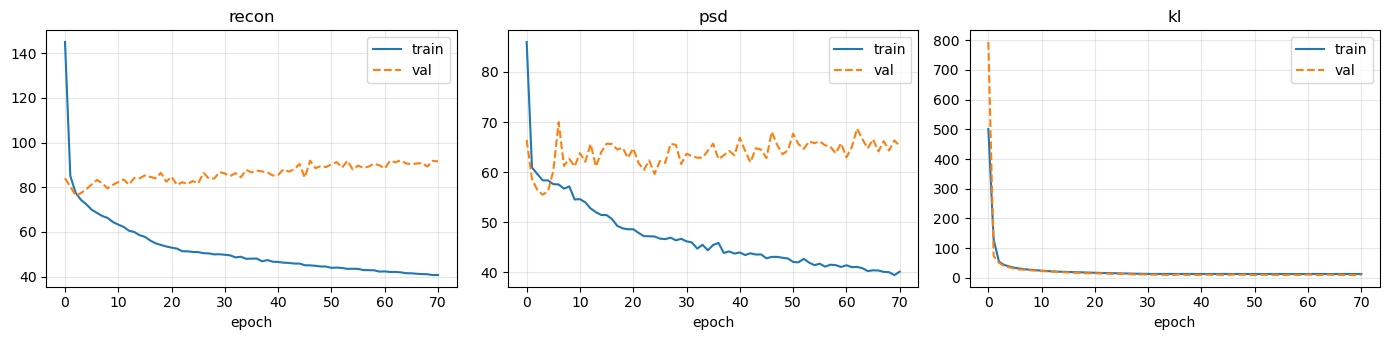

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
for k, a in zip(['recon', 'psd', 'kl'], ax):
    a.plot([h[k] for h in history['train']], label='train')
    a.plot([h[k] for h in history['val']],   label='val', linestyle='--')
    a.set_title(k); a.set_xlabel('epoch'); a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('train_curves.png', dpi=130); plt.show()

## 7. Reconstruccion vs real

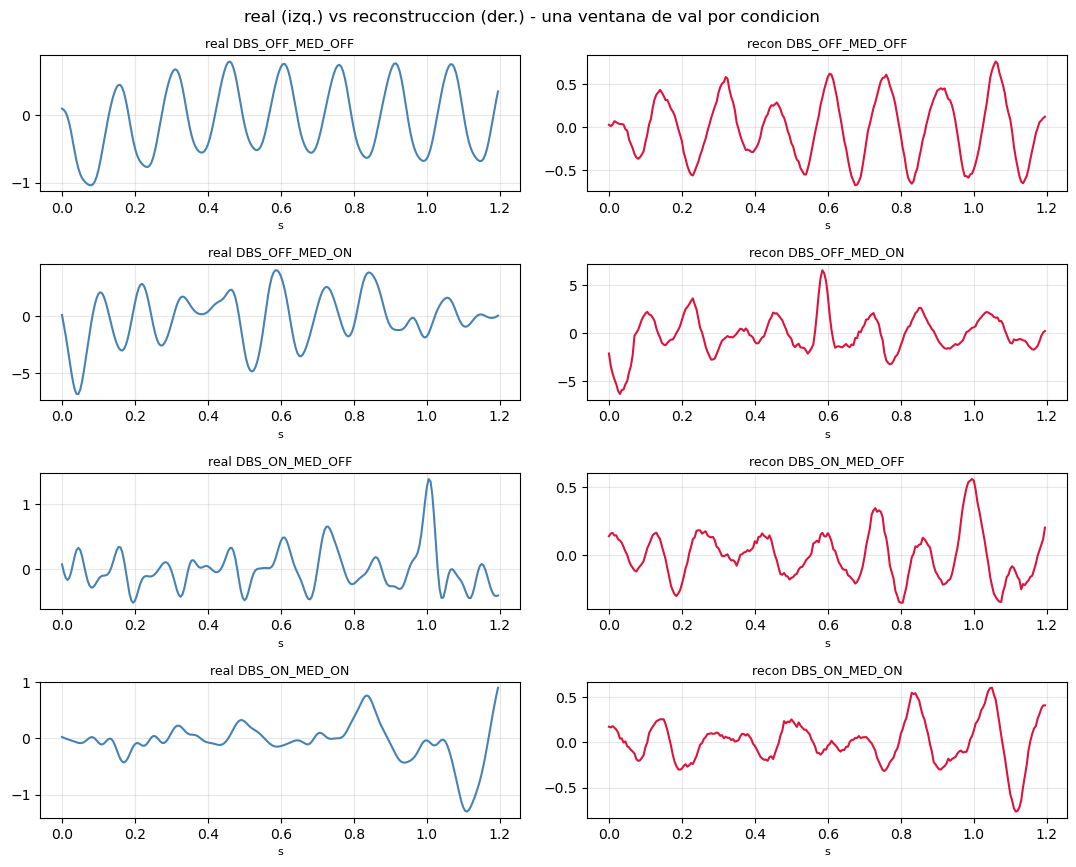

In [8]:
model.eval()
COND_INV = {v: k for k, v in LABELS['condition'].items()}
fig, axes = plt.subplots(N_COND, 2, figsize=(11, 2.2 * N_COND))
fig.suptitle('real (izq.) vs reconstruccion (der.) - una ventana de val por condicion')

with torch.no_grad():
    for ci in range(N_COND):
        idxs = np.where(y_val[:, 0] == ci)[0]
        if len(idxs) == 0:
            for j in (0, 1):
                axes[ci, j].text(0.5, 0.5, 'sin datos', ha='center', va='center', transform=axes[ci, j].transAxes)
            continue
        idx = idxs[0]
        x = torch.from_numpy(X_val[idx:idx+1]).float().unsqueeze(1).to(device)
        c = torch.tensor([ci], dtype=torch.long, device=device)
        x_hat, _, _ = model(x, c)
        t = np.arange(WINDOW_LEN) / FS
        axes[ci, 0].plot(t, x.squeeze().cpu().numpy(),     color='steelblue')
        axes[ci, 1].plot(t, x_hat.squeeze().cpu().numpy(), color='crimson')
        axes[ci, 0].set_title(f'real {COND_INV[ci]}',  fontsize=9)
        axes[ci, 1].set_title(f'recon {COND_INV[ci]}', fontsize=9)
        for j in (0, 1):
            axes[ci, j].grid(alpha=0.3); axes[ci, j].set_xlabel('s', fontsize=8)
plt.tight_layout(); plt.savefig('recon_check.png', dpi=130); plt.show()

## 8. Muestreo condicional

In [9]:
def sample_cvae(model, condition_idx, n_samples, latent=LATENT_DIM, n_cond=N_COND, device=device):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, latent, device=device)
        c = torch.zeros(n_samples, n_cond, device=device)
        c[:, condition_idx] = 1.0
        return model.decode(z, c).squeeze(1).cpu().numpy()

N_PER_COND = 1000
synth_X, synth_y = [], []
for c, idx in LABELS['condition'].items():
    synth_X.append(sample_cvae(model, idx, N_PER_COND))
    synth_y.append(np.full(N_PER_COND, idx))
synth_X = np.concatenate(synth_X).astype(np.float32)
synth_y = np.concatenate(synth_y).astype(np.int64)
np.save('synth_X.npy', synth_X); np.save('synth_y.npy', synth_y)
print(f'synth X {synth_X.shape}, y {synth_y.shape}')

synth X (4000, 240), y (4000,)


## 9. PSD real vs sintetico

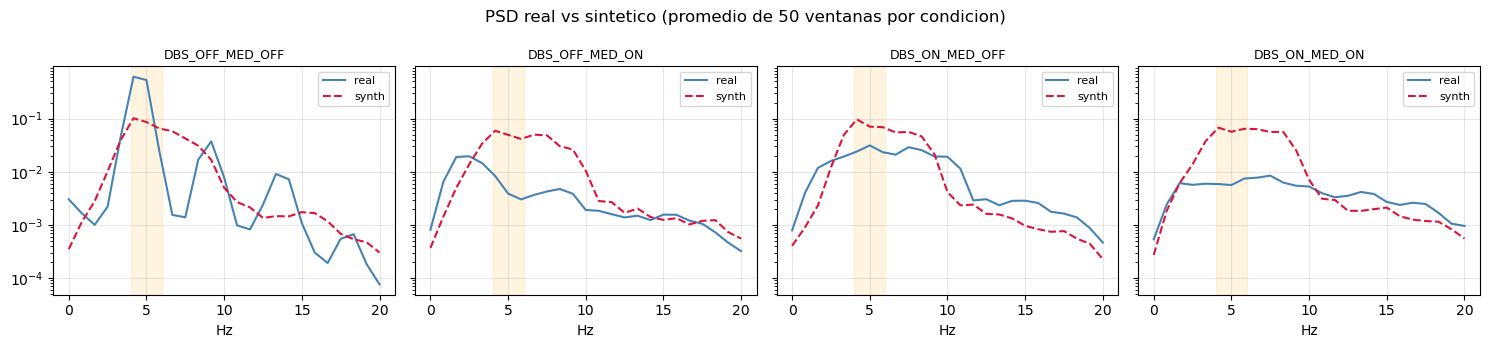

In [10]:
fig, axes = plt.subplots(1, N_COND, figsize=(15, 3.5), sharey=True)
fig.suptitle('PSD real vs sintetico (promedio de 50 ventanas por condicion)')

for ci, ax in enumerate(axes):
    real_idxs = np.where(y_train[:, 0] == ci)[0][:50]
    fake_idxs = np.where(synth_y == ci)[0][:50]
    if len(real_idxs) == 0 or len(fake_idxs) == 0:
        ax.text(0.5, 0.5, 'sin datos', ha='center', va='center', transform=ax.transAxes); continue
    psd_real = np.stack([sp_signal.welch(X_train[i], fs=FS, nperseg=WINDOW_LEN)[1] for i in real_idxs]).mean(0)
    psd_fake = np.stack([sp_signal.welch(synth_X[i], fs=FS, nperseg=WINDOW_LEN)[1] for i in fake_idxs]).mean(0)
    f_axis = sp_signal.welch(X_train[real_idxs[0]], fs=FS, nperseg=WINDOW_LEN)[0]
    mask = f_axis <= 20
    ax.semilogy(f_axis[mask], psd_real[mask], color='steelblue', lw=1.5, label='real')
    ax.semilogy(f_axis[mask], psd_fake[mask], color='crimson',   lw=1.5, label='synth', linestyle='--')
    ax.axvspan(4, 6, color='orange', alpha=0.12)
    ax.set_title(COND_INV[ci], fontsize=9); ax.set_xlabel('Hz')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('psd_real_vs_synth.png', dpi=130); plt.show()

## Resumen

| Item | Valor |
|---|---|
| Modelo | 1D Conv CVAE, encoder y decoder condicionados, latent=16 |
| Perdida | MSE + 0.1 * PSD-MAE + beta * max(KL_dim - 0.5, 0) |
| beta-annealing | 0 -> 1 en 30 epocas |
| Optimizador | AdamW, lr=1e-3, cosine, early stopping |
| Salidas | `cvae_best.pt`, `synth_X.npy`, `synth_y.npy` |

Etapa 3: usar `synth_X` para tests de fidelidad y demo de power.